**Description Of the features of the dataset:**


Y – Latitude coordinate of the observation station.

X – Longitude coordinate of the observation station.

data_payload_id – Unique identifier for the data record.

instance_datetime – Timestamp when the data was recorded.

url – URL reference to the data source.

agency – Organization responsible for the data.

platform_type – Type of platform (e.g., station, balloon, etc.).

platform_id – Numeric ID for the platform.

platform_name – Name of the observation platform or station.

gaw_id – Global Atmosphere Watch ID of the platform.

instrument_name – Name of the instrument used for measurement.

instrument_model – Model of the instrument.

instrument_number – Instrument's identification number.

monthly_date – Date associated with monthly aggregated data.

monthly_columno3 – Monthly average ozone column value.

monthly_stddevo3 – Standard deviation of the monthly ozone values.

monthly_npts – Number of observations used in monthly average.

daily_date – Date of the daily observation.

daily_wlcode – Wavelength code used during observation.

daily_obscode – Observation code (e.g., method or technique).

daily_columno3 – Daily ozone column measurement (Dobson Units).

daily_stddevo3 – Standard deviation of the daily ozone value.

daily_utc_begin – UTC time when observation began.

daily_utc_end – UTC time when observation ended.

daily_utc_mean – Mean UTC time of observation.

daily_nobs – Number of observations for that day.

daily_mmu – Measurement uncertainty for daily ozone.

daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.

latest_observation – Flag indicating if this is the most recent data (0 or 1).

country – Country of the observation station.

scientific_authority – Name of the responsible scientist or authority.

version – Version number of the data record.

In [2]:
%pip install lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import  LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


/home/t2420363/miniconda3/envs/rapids-23.12/lib/python3.10/site-packages/dask/array/chunk_types.py:110: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda11x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  import cupy
/home/t2420363/miniconda3/envs/rapids-23.12/lib/python3.10/site-packages/optuna/study/_optimize.py:21

In [3]:
df=pd.read_csv('New Dataset/spain.csv')
df.head()


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,28.46,-16.25,2306481,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.15,10.52,9.60,4.0,2.181,-0.5,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
1,28.46,-16.25,2306502,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.50,17.88,15.22,12.0,1.421,-1.4,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
2,28.46,-16.25,2306482,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,8.85,14.03,10.80,16.0,1.638,-0.9,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
3,28.46,-16.25,2306480,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.83,17.27,15.41,10.0,1.602,-0.6,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
4,28.46,-16.25,2306483,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.55,17.55,15.04,19.0,1.680,-0.8,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0


In [4]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [5]:
print(f"Date Range: {df.loc[:,'daily_date'][len(df)-1]} to {df.loc[:,'daily_date'][0]}")

Date Range: 1976-01-21 to 2025-03-06


In [6]:
df=df.drop_duplicates()
df=df.dropna()
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()
df.head()


,daily_date,daily_columno3
0,1976-01-13,264.0
1,1976-01-14,257.2
2,1976-01-16,296.2
3,1976-01-17,308.9
4,1976-01-18,351.7


In [7]:
round(df.describe(), 3)

,daily_columno3
count,13229.000
mean,309.595
std,28.472
min,210.640
25%,290.100
50%,305.767
75%,326.000
max,477.667


In [8]:
df.head()
df.dtypes

daily_date         object
daily_columno3    float64
dtype: object

<Figure size 1200x600 with 0 Axes>

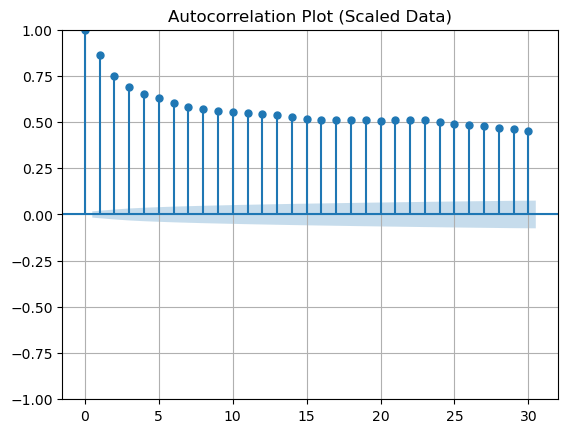

✅ Autocorrelation remains significant for all plotted lags.


In [9]:

acf_vals, confint = acf(df['daily_columno3'], nlags=30, alpha=0.05)

# 4. Calculate threshold from confidence interval
threshold = (confint[:,1] - confint[:,0]) / 2

# 5. Find first inconsistent lag
inconsistent_lag = None
for i, val in enumerate(acf_vals):
    if i == 0:  # Skip lag 0
        continue
    if abs(val) < threshold[i]:
        inconsistent_lag = i
        break

# 6. Plot ACF
plt.figure(figsize=(12,6))
plot_acf(df['daily_columno3'], lags=30, alpha=0.05)
plt.title('Autocorrelation Plot (Scaled Data)')
plt.grid()
plt.show()

# 7. Print result
if inconsistent_lag:
    print(f"👉 Autocorrelation becomes inconsistent after lag {inconsistent_lag}.")
else:
    print("✅ Autocorrelation remains significant for all plotted lags.")



In [ ]:
df.head()

In [10]:
# 2. Sort the dataframe by the full date (oldest to latest)
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (3-day) - To Avoid data leakage, we shift the column by 1 day
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=7).mean()

# Exponential moving average feature (7-day) - To Avoid data leakage, we shift the column by 1 day
df['ema_avg'] = df['daily_columno3'].shift(1).ewm(span=7, adjust=False).mean()


for i in range(1, 61):
    df[f'lag{i}'] = df['daily_columno3'].shift(i)


df.dropna(inplace=True)
print(df.shape)
df.head()

(13169, 64)


,daily_date,daily_columno3,rolling_avg,ema_avg,lag1,lag2,lag3,lag4,lag5,lag6,...,lag51,lag52,lag53,lag54,lag55,lag56,lag57,lag58,lag59,lag60
60,1980-02-26,340.0,291.528571,290.176070,286.0,287.4,297.2,311.8,294.2,267.9,...,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2,264.0
61,1980-02-27,308.0,297.785714,302.632053,340.0,286.0,287.4,297.2,311.8,294.2,...,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2
62,1980-03-05,424.0,303.514286,303.974039,308.0,340.0,286.0,287.4,297.2,311.8,...,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2
63,1980-03-06,323.0,322.057143,333.980530,424.0,308.0,340.0,286.0,287.4,297.2,...,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9
64,1980-03-12,373.0,323.657143,331.235397,323.0,424.0,308.0,340.0,286.0,287.4,...,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7


In [ ]:
df.tail()

**Using Rolling Average**

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Support Vector Regressor...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15555
[LightGBM] [Info] Number of data points in the train set: 10535, number of used features: 61
[LightGBM] [Info] Start training from score 0.000000
Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.413
MAE : 0.293
R2  : 81.57 %

----- Decision Tree -----
RMSE: 0.626
MAE : 0.444
R2  : 57.55 %

----- Random Forest -----
RMSE: 0.416
MAE : 0.294
R2  : 81.22 %

----- Gradient Boosting -----
RMSE: 0.414
MAE : 0.294
R2  : 81.42 %

----- Support Vector Regressor -----
RMSE: 0.451
MAE : 0.312
R2  : 78.00 %

----- XGBoost -----
RMSE: 0.439
MAE : 0.307
R2  : 79.17 %

----- LightGBM -----
RMSE: 0.415
MAE 

/home/t2420363/miniconda3/envs/rapids-23.12/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


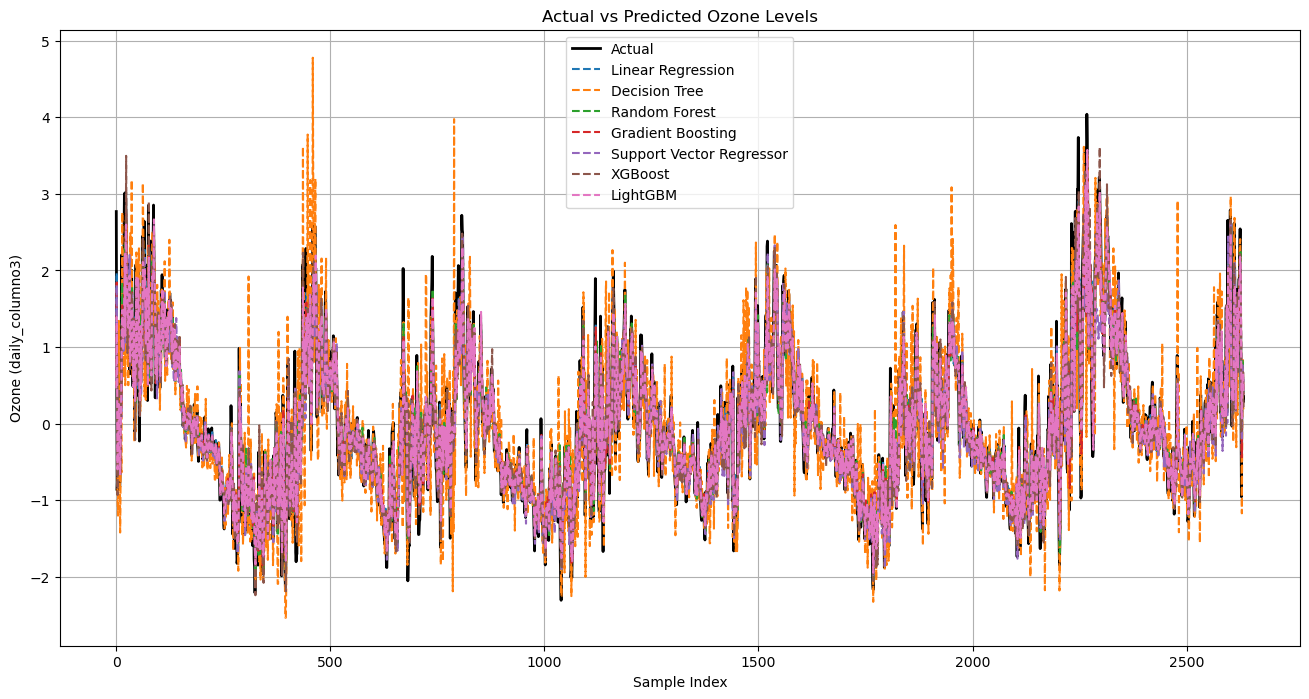

In [13]:
minmax_x = StandardScaler()
minmax_y= StandardScaler()

lag_features = [f'lag{i}' for i in range(1, 61)]
lag_features.append('rolling_avg')
# lag_features.append('ema_avg')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

***Hyper Parameter Tuning On Simple Rolling Average**


Training Linear Regression...

Training Decision Tree...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Decision Tree Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}

Training Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Training Gradient Boosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Gradient Boosting Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.1}

Training Support Vector Regressor...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Support Vector Regressor Best Parameters: {'kernel': 'linear', 'epsilon': 0.01, 'C': 1}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.044
MAE : 0.031
R2  : 81.57 %

----- Decision Tree -----
RMSE: 0.046
MAE : 0.033
R2  : 80.01 %

----- Random Forest -

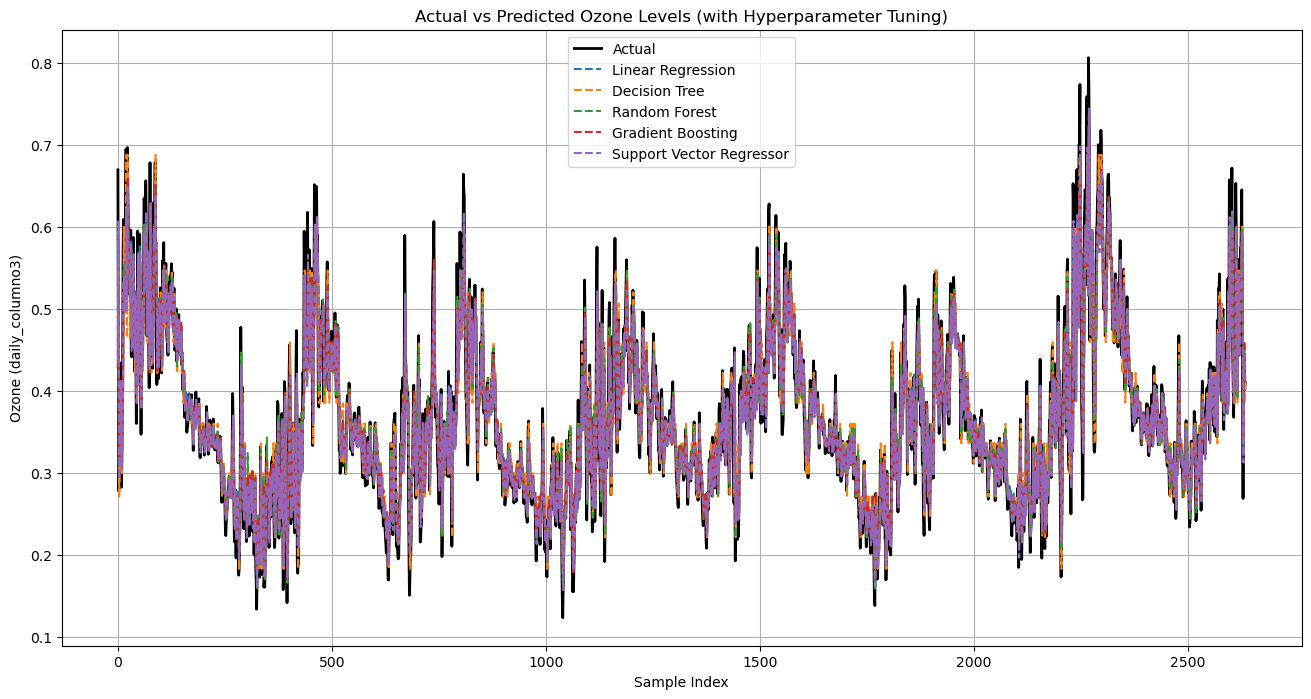

In [25]:

from sklearn.model_selection import RandomizedSearchCV,ParameterGrid


X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Define models (with GPU enabled where supported)
models = {
   
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),

}

# Define hyperparameter grids
param_grids = {
        
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    },
    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'epsilon': [0.1, 0.01]
    }

}

# Models that will use RandomizedSearchCV
use_randomized_search = {
  'Random Forest', 'Gradient Boosting', 'Support Vector Regressor'
}

# Run tuning and evaluation
best_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if param_grids[name]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10 if name in use_randomized_search else len(list(ParameterGrid(param_grids[name]))),
            cv=3,  # reduced for speed
            scoring='r2',
            n_jobs=2,
            verbose=1,
            random_state=42
        )
        # Fix for AttributeError: 'super' object has no attribute '__sklearn_tags__'
        # Some third-party estimators (e.g., XGBRegressor, LGBMRegressor) may not implement all sklearn tags.
        # This workaround disables tag checking for these models.
        try:
            search.fit(X_train, y_train)
        except AttributeError as e:
            if "__sklearn_tags__" in str(e):
                # Monkey patch the estimator to add __sklearn_tags__ if missing
                def _dummy_tags(self):
                    return {}
                setattr(type(search.estimator), "__sklearn_tags__", _dummy_tags)
                search.fit(X_train, y_train)
            else:
                raise
        best_models[name] = search.best_estimator_
        print(f"{name} Best Parameters: {search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # Make predictions and calculate metrics
    preds = best_models[name].predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Model': best_models[name],
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Print metrics
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# Plot predictions
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels (with Hyperparameter Tuning)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()





**Using Exponantial Average**


Training Linear Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training Support Vector Regressor...
Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.044
MAE : 0.031
R2  : 81.56 %

----- Decision Tree -----
RMSE: 0.068
MAE : 0.047
R2  : 57.22 %

----- Random Forest -----
RMSE: 0.045
MAE : 0.031
R2  : 81.39 %

----- Gradient Boosting -----
RMSE: 0.044
MAE : 0.032
R2  : 81.45 %

----- Support Vector Regressor -----
RMSE: 0.053
MAE : 0.039
R2  : 74.07 %



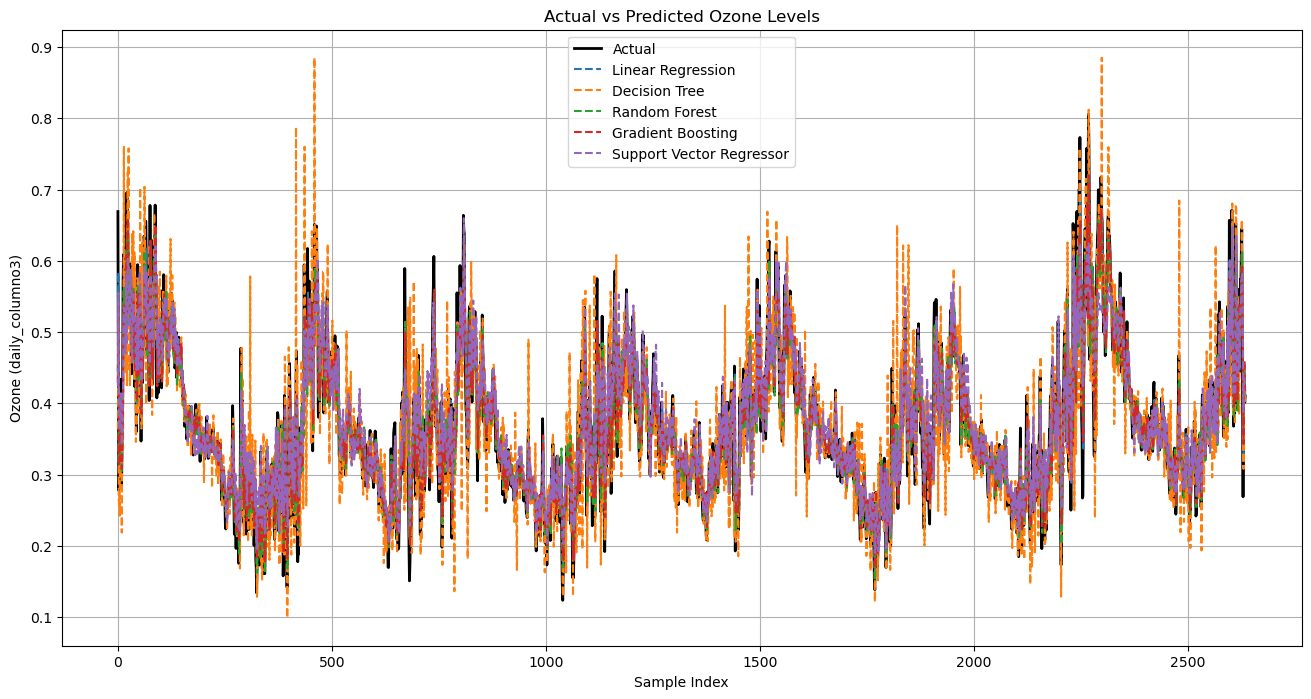

In [26]:
minmax_x = MinMaxScaler()
minmax_y= MinMaxScaler()
lag_features = [f'lag{i}' for i in range(1, 61)]
# lag_features.append('rolling_avg')
lag_features.append('ema_avg')
X = df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

**Hyper Parameter Tuning on Exponential Moving Average**


Training Linear Regression...

Training Decision Tree...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}

Training Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}

Training Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Gradient Boosting Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.1}

Training Support Vector Regressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Support Vector Regressor Best Parameters: {'kernel': 'linear', 'epsilon': 0.01, 'C': 1}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.044
MAE : 0.031
R2  : 81.57 %

----- Decision Tree -----
RMSE: 0.046
MAE : 0.033
R2  : 80.04 %

----- Random Forest -

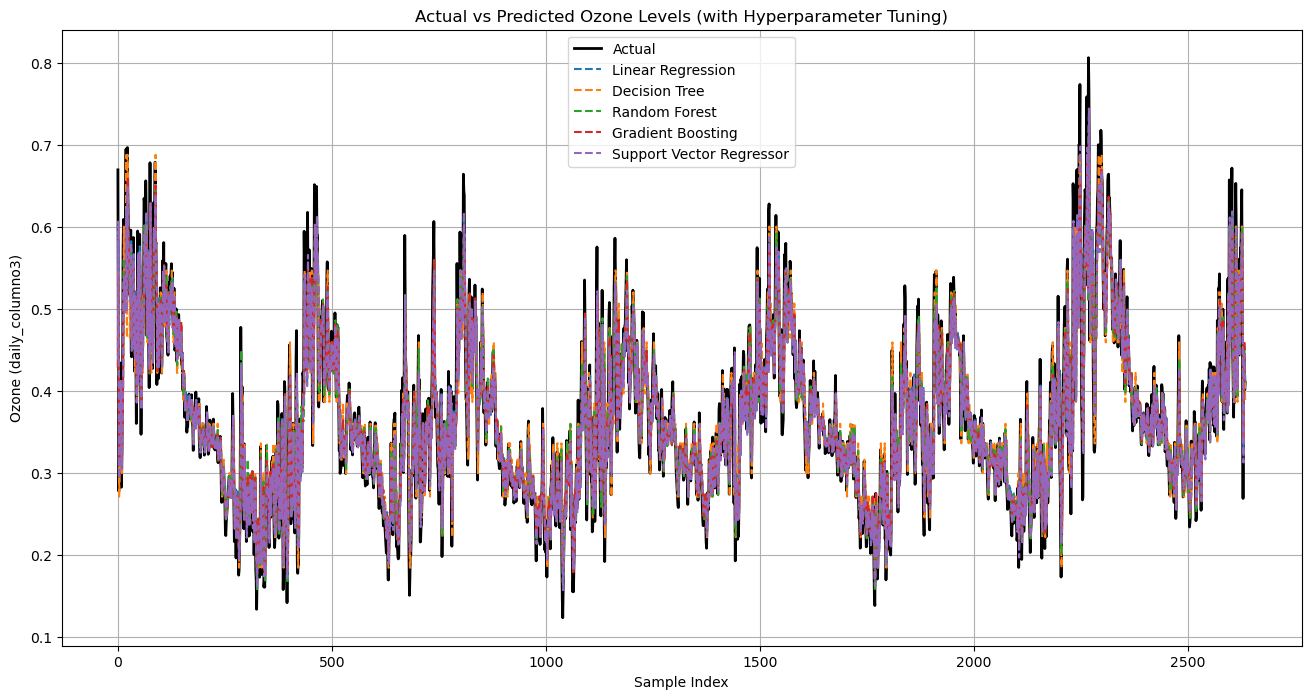

In [27]:

from sklearn.model_selection import RandomizedSearchCV,ParameterGrid
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
}

# Define hyperparameter grids
param_grids = {
    'Linear Regression': {},

    'Decision Tree': {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    },

    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'epsilon': [0.1, 0.01]
    },

  
}

# Models that will use RandomizedSearchCV
use_randomized_search = {
   'Random Forest', 'Gradient Boosting', 'Support Vector Regressor'
}

# Run tuning and evaluation
best_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if param_grids[name]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10 if name in use_randomized_search else len(list(ParameterGrid(param_grids[name]))),
            cv=5,
            scoring='r2',
            n_jobs=2,
            verbose=1,
            random_state=42
        )

        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        print(f"{name} Best Parameters: {search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # Make predictions and calculate metrics
    preds = best_models[name].predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Model': best_models[name],
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Print metrics
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# Plot predictions
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels (with Hyperparameter Tuning)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()